<a href="https://colab.research.google.com/github/aditi-tawade-ai/aditi-tawade-ai/blob/main/ML_Practice/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Assignment confusion matrix for multiclass classification
# if we have more thN 2 catg in predctn then how to read confusion matrix
# how to understaand TP,TN,FP,FN

In [2]:
# Assignment: Test all other algorithm

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [3]:
# create 1 dataframe to display the values in comparison for all algorithms
# Algo|precision|recall|f1|accuracy

In [4]:
import pandas as pd
path = '/content/archive.zip'
w = pd.read_csv(path)
w[:2]

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050


In [5]:
# step 2 data processing
w.isna().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


From above table we know that there are no missing values

In [6]:
# step 3 - analysis
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# choosing input values
w.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

In [8]:
x = ['Wine','Alcohol', 'Malic.acid','Phenols','Flavanoids']

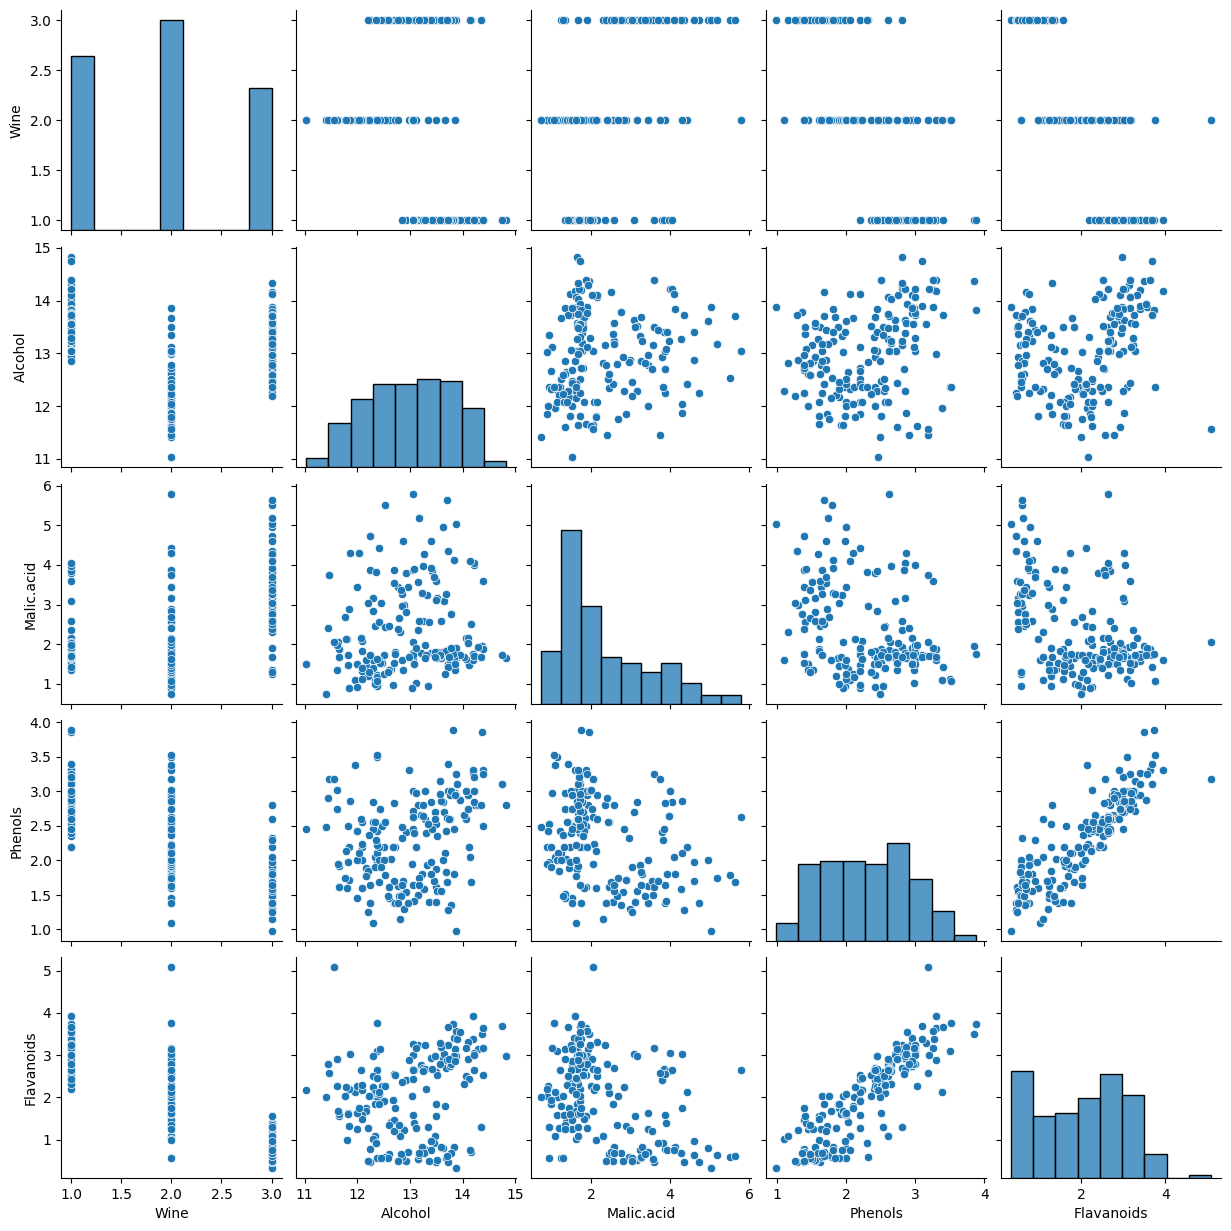

In [9]:
sns.pairplot(data=w[x])

In [10]:
w.Wine.unique()

array([1, 2, 3])

from above observation we understand that it is a logestic regression data set

In [11]:
# prepare the data
X = w[['Alcohol', 'Malic.acid','Phenols','Flavanoids']]
y = w['Wine']

In [12]:
# spliting of data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [13]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model

LogisticRegression()

In [14]:
# we used standardscalar becoz we have numbers / inputs in different range
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
# training data
model.fit(X_train,y_train)

LogisticRegression()

In [16]:
# testing data
y_pred = model.predict(X_test)
y_pred

array([3, 1, 3, 2, 2, 2, 2, 1, 1, 1, 1, 2, 3, 2, 1, 2, 2, 1, 3, 3, 1, 2,
       3, 3, 1, 1, 1, 2, 3, 2, 2, 1, 3, 3, 1, 3])

In [17]:
# comparing actual with predicted
y_test.values

array([3, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 3, 1, 1, 2, 2, 1, 3, 3, 2, 2,
       3, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 1, 3])

In [18]:
# introducing confusion matrics
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
cm = confusion_matrix(y_test,y_pred)
cm

array([[11,  2,  0],
       [ 2, 10,  1],
       [ 0,  0, 10]])

<Axes: >

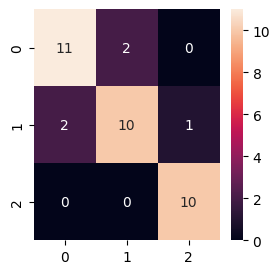

In [19]:
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True)

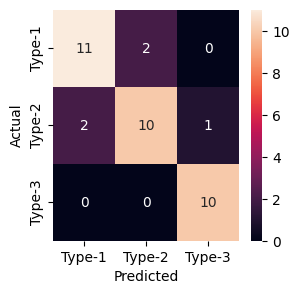

In [20]:
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True,xticklabels=['Type-1','Type-2','Type-3'],yticklabels=['Type-1','Type-2','Type-3'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
# accuracy = tn+tp/total
31/36

0.8611111111111112

In [22]:
accuracy_score(y_test,y_pred)*100

86.11111111111111

In [23]:
# precision score
precision_score(y_test,y_pred,average='micro')*100

86.11111111111111

In [24]:
precision_score(y_test,y_pred,average='macro')*100

86.28593628593629

In [25]:
precision_score(y_test,y_pred,average='weighted')*100

85.9006734006734

- micro - combines all classes together and div with total just as accuracy

- macro - calculates precision for each column seperatly then adds and give mean of all classes giving importance to each class

- weighted - it gives imortance to the class which has more value


In [26]:
recall_score(y_test,y_pred,average='micro')*100

86.11111111111111

In [27]:
recall_score(y_test,y_pred,average='macro')*100

87.17948717948718

In [28]:
recall_score(y_test,y_pred,average='weighted')*100

86.11111111111111

In [29]:
f1_score(y_test,y_pred,average='micro')*100

86.11111111111111

In [30]:
f1_score(y_test,y_pred,average='macro')*100

86.61782661782661

In [31]:
f1_score(y_test,y_pred,average='weighted')*100

85.8994708994709

In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.85      0.85      0.85        13
           2       0.83      0.77      0.80        13
           3       0.91      1.00      0.95        10

    accuracy                           0.86        36
   macro avg       0.86      0.87      0.87        36
weighted avg       0.86      0.86      0.86        36



In [33]:
# Assignment: Test all other algorithm

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [34]:
model = RandomForestClassifier()
model.fit(X_train,y_train)
model

RandomForestClassifier()

In [35]:
rc = model.predict(X_test)
rc

array([3, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 3, 1, 1, 2, 2, 1, 3, 3, 1, 2,
       3, 3, 1, 1, 1, 2, 3, 3, 2, 1, 3, 3, 1, 3])

In [36]:
y_test.values

array([3, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 3, 1, 1, 2, 2, 1, 3, 3, 2, 2,
       3, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 1, 3])

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rc))

              precision    recall  f1-score   support

           1       0.87      1.00      0.93        13
           2       1.00      0.77      0.87        13
           3       0.91      1.00      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.93      0.92      0.91        36



In [39]:
from sklearn.neighbors import KNeighborsClassifier
mdl = KNeighborsClassifier()
mdl.fit(X_train,y_train)
mdl

KNeighborsClassifier()

In [40]:
kn = mdl.predict(X_test)
kn

array([3, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 3, 3, 1, 2,
       3, 1, 1, 1, 1, 2, 2, 2, 2, 1, 3, 3, 1, 3])

In [41]:
y_test.values

array([3, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 3, 1, 1, 2, 2, 1, 3, 3, 2, 2,
       3, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 1, 3])

In [48]:
print(classification_report(y_test,kn))

              precision    recall  f1-score   support

           1       0.81      1.00      0.90        13
           2       0.85      0.85      0.85        13
           3       1.00      0.70      0.82        10

    accuracy                           0.86        36
   macro avg       0.89      0.85      0.86        36
weighted avg       0.88      0.86      0.86        36



In [43]:
from sklearn.svm import SVC
md = SVC()
md.fit(X_train,y_train)
md

SVC()

In [44]:
sv = md.predict(X_test)
sv

array([3, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 3, 3, 1, 2,
       3, 2, 1, 2, 1, 2, 2, 2, 2, 1, 3, 3, 1, 3])

In [45]:
y_test.values

array([3, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 3, 1, 1, 2, 2, 1, 3, 3, 2, 2,
       3, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 1, 3])

In [49]:
print(classification_report(y_test,sv))

              precision    recall  f1-score   support

           1       0.92      0.92      0.92        13
           2       0.75      0.92      0.83        13
           3       1.00      0.70      0.82        10

    accuracy                           0.86        36
   macro avg       0.89      0.85      0.86        36
weighted avg       0.88      0.86      0.86        36



In [50]:
from sklearn.naive_bayes import GaussianNB
m = GaussianNB()
m.fit(X_train,y_train)
m

GaussianNB()

In [51]:
gnb_pred = m.predict(X_test)
gnb_pred

array([3, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 3, 3, 1, 2,
       3, 2, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 1, 3])

In [53]:
print(classification_report(y_test,gnb_pred))

              precision    recall  f1-score   support

           1       0.92      0.85      0.88        13
           2       0.75      0.92      0.83        13
           3       1.00      0.80      0.89        10

    accuracy                           0.86        36
   macro avg       0.89      0.86      0.87        36
weighted avg       0.88      0.86      0.86        36



In [ ]:
# create 1 dataframe to display the values in comparison for all algorithms
# Algo|precision|recall|f1|accuracy

In [62]:
import pandas as pd
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

results = {'Algorithms':[
           'Logistic Regression',
           'Random Forest',
           'KNN',
           'SVM',
           'Naive Bayes'],
           'Accuracy':[
               accuracy_score(y_test,y_pred),
               accuracy_score(y_test,rc),
               accuracy_score(y_test,kn),
               accuracy_score(y_test,sv),
               accuracy_score(y_test,gnb_pred)],
           'Precision Score':[
               precision_score(y_test,y_pred,average='macro'),
               precision_score(y_test,rc,average='macro'),
               precision_score(y_test,kn,average='macro'),
               precision_score(y_test,sv,average='macro'),
               precision_score(y_test,gnb_pred,average='macro')],
           'Rrcall Score':[
               recall_score(y_test,y_pred,average='macro'),
               recall_score(y_test,rc,average='macro'),
               recall_score(y_test,kn,average='macro'),
               recall_score(y_test,sv,average='macro'),
               recall_score(y_test,gnb_pred,average='macro')],
           'F1 score':[
               f1_score(y_test,y_pred,average='macro'),
               f1_score(y_test,rc,average='macro'),
               f1_score(y_test,kn,average='macro'),
               f1_score(y_test,sv,average='macro'),
               f1_score(y_test,gnb_pred,average='macro')
           ]
           }
df = pd.DataFrame(results)
df


,Algorithms,Accuracy,Precision Score,Rrcall Score,F1 score
0,Logistic Regression,0.861111,0.862859,0.871795,0.866178
1,Random Forest,0.916667,0.925253,0.923077,0.916839
2,KNN,0.861111,0.886218,0.848718,0.855412
3,SVM,0.861111,0.891026,0.848718,0.858064
4,Naive Bayes,0.861111,0.888889,0.856410,0.865492
